Lab 26.2 – Part 2: Evaluation & Optimization
Goal:

Use cross-validation (CV) for reliable performance estimates,

Apply GridSearchCV / RandomizedSearchCV to optimize hyperparameters,

Compare tuned models vs baselines,

Save the best model for later deployment.

We’ll continue with the Titanic dataset (classification).

In [1]:
# pip install scikit-learn seaborn pandas numpy matplotlib
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, make_scorer
from scipy.stats import randint
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [2]:
df = sns.load_dataset("titanic").drop(columns=["alive"])
target = "survived"
features = ['pclass','sex','age','sibsp','parch','fare','embarked','class','who','alone']
df = df[features+[target]].copy()
df[target] = df[target].astype(int)
 
X = df[features]; y = df[target]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Preprocessing

In [3]:
num_cols = Xtr.select_dtypes(include="number").columns.tolist()
cat_cols = Xtr.select_dtypes(exclude="number").columns.tolist()
 
numeric_pre = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
categorical_pre = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                            ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
 
preprocess = ColumnTransformer([("num", numeric_pre, num_cols),
                                ("cat", categorical_pre, cat_cols)])

Baseline models (from Part 1)

In [4]:
logreg = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=2000))])
rf = Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1))])

Cross-validation evaluation

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
from sklearn.model_selection import cross_validate
 
for name, model in [("LogReg", logreg), ("RF", rf)]:
    scores = cross_validate(model, X, y, cv=cv,
                            scoring={"acc":"accuracy","f1":"f1","roc":"roc_auc"})
    print(f"\n{name} CV mean±std:")
    for m in ["acc","f1","roc"]:
        print(f"{m}: {scores['test_'+m].mean():.3f} ± {scores['test_'+m].std():.3f}")


LogReg CV mean±std:
acc: 0.822 ± 0.007
f1: 0.760 ± 0.014
roc: 0.866 ± 0.022

RF CV mean±std:
acc: 0.817 ± 0.027
f1: 0.759 ± 0.030
roc: 0.872 ± 0.022


 Hyperparameter tuning — Logistic Regression

In [6]:
param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 5, 10],
    "clf__penalty": ["l2"],  # L2 works with 'lbfgs'
    "clf__solver": ["lbfgs"]
}
 
grid_lr = GridSearchCV(logreg, param_grid_lr, cv=cv,
                       scoring="roc_auc", n_jobs=-1).fit(Xtr, ytr)
 
print("Best Logistic Regression params:", grid_lr.best_params_)
print("Best CV ROC-AUC:", round(grid_lr.best_score_,3))

Best Logistic Regression params: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV ROC-AUC: 0.863


C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


 Hyperparameter tuning — Random Forest
Use RandomizedSearchCV for efficiency.

In [7]:
param_dist_rf = {
    "clf__n_estimators": randint(200,600),
    "clf__max_depth": [None, 5, 10, 20],
    "clf__min_samples_split": randint(2,10),
    "clf__min_samples_leaf": randint(1,5)
}
 
rand_rf = RandomizedSearchCV(rf, param_dist_rf, cv=cv, n_iter=15,
                             scoring="roc_auc", n_jobs=-1, random_state=0).fit(Xtr, ytr)
 
print("Best RF params:", rand_rf.best_params_)
print("Best CV ROC-AUC:", round(rand_rf.best_score_,3))

Best RF params: {'clf__max_depth': None, 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 3, 'clf__n_estimators': 239}
Best CV ROC-AUC: 0.88


Evaluate tuned models on hold-out test

In [8]:
best_lr = grid_lr.best_estimator_
best_rf = rand_rf.best_estimator_
 
for name, model in [("Tuned LogReg", best_lr), ("Tuned RF", best_rf)]:
    yhat = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    print(f"\n{name} Hold-out:")
    print("Acc :", round(accuracy_score(yte, yhat),3))
    print("F1  :", round(f1_score(yte, yhat),3))
    print("ROC :", round(roc_auc_score(yte, proba),3))


Tuned LogReg Hold-out:
Acc : 0.821
F1  : 0.75
ROC : 0.866

Tuned RF Hold-out:
Acc : 0.821
F1  : 0.742
ROC : 0.848


Visualize CV results

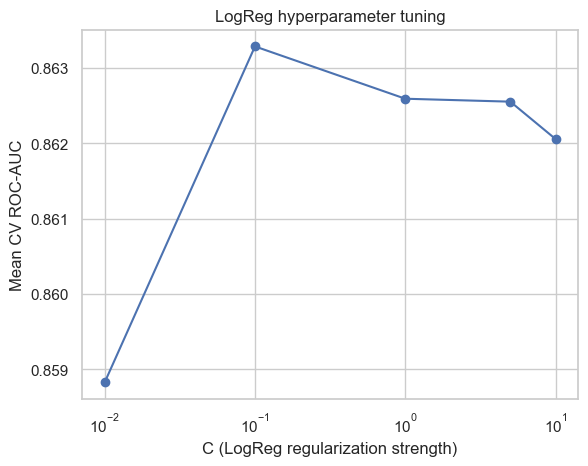

In [9]:
results_df = pd.DataFrame(grid_lr.cv_results_)
plt.semilogx(results_df["param_clf__C"], results_df["mean_test_score"], marker="o")
plt.xlabel("C (LogReg regularization strength)"); plt.ylabel("Mean CV ROC-AUC")
plt.title("LogReg hyperparameter tuning"); plt.show()

Extend tuning for RandomForest with more parameters (e.g., max_features, bootstrap) and compare ROC-AUC.

In [10]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 1. Generate synthetic binary classification data
X, y = make_classification(
    n_samples=2000, 
    n_features=20, 
    n_informative=10, 
    n_redundant=5, 
    random_state=42
)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ---------------------------------------------------------
# 2. Baseline Model (Default Parameters)
# ---------------------------------------------------------
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

# Predict probabilities for the positive class (required for ROC-AUC)
y_pred_proba_default = rf_default.predict_proba(X_test)[:, 1]
auc_default = roc_auc_score(y_test, y_pred_proba_default)

print(f"Baseline Random Forest ROC-AUC: {auc_default:.4f}")

# ---------------------------------------------------------
# 3. Extended Hyperparameter Tuning
# ---------------------------------------------------------

# Define the extended parameter grid
# Including max_features and bootstrap as requested
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    
    # New parameters added:
    'max_features': ['sqrt', 'log2'], # Number of features to consider at every split
    'bootstrap': [True, False]        # Whether bootstrap samples are used when building trees
}

# Initialize the classifier
rf = RandomForestClassifier(random_state=42)

# Setup GridSearchCV
# scoring='roc_auc' ensures the tuning optimizes for AUC specifically
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1,
    scoring='roc_auc'
)

# Fit the grid search
print("\nStarting Grid Search...")
grid_search.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. Compare Results
# ---------------------------------------------------------

# Get the best model
best_rf = grid_search.best_estimator_

print(f"\nBest Parameters found: {grid_search.best_params_}")

# Predict probabilities with the tuned model
y_pred_proba_tuned = best_rf.predict_proba(X_test)[:, 1]
auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

print(f"Tuned Random Forest ROC-AUC:    {auc_tuned:.4f}")

# Calculate Improvement
improvement = (auc_tuned - auc_default) / auc_default * 100
print(f"Improvement: {improvement:.2f}%")


Baseline Random Forest ROC-AUC: 0.9715

Starting Grid Search...
Fitting 3 folds for each of 96 candidates, totalling 288 fits

Best Parameters found: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Tuned Random Forest ROC-AUC:    0.9734
Improvement: 0.20%


Add a GradientBoostingClassifier or XGBClassifier, tune learning_rate and n_estimators. Does boosting beat RF?

In [11]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

# 1. Generate synthetic binary classification data
# Increased difficulty (more redundant features) to highlight model differences
X, y = make_classification(
    n_samples=2000, 
    n_features=25, 
    n_informative=10, 
    n_redundant=10, 
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ==========================================
# Part A: Random Forest Tuning (Baseline)
# ==========================================
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

print("Tuning Random Forest...")
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

# ==========================================
# Part B: Gradient Boosting Tuning
# ==========================================
gb = GradientBoostingClassifier(random_state=42)

# Boosting is sensitive to the relationship between learning_rate and n_estimators.
# Lower learning_rate usually requires higher n_estimators.
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5] # Boosting usually prefers shallow trees (stumps)
}

print("Tuning Gradient Boosting...")
gb_grid = GridSearchCV(gb, gb_params, cv=3, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_
gb_auc = roc_auc_score(y_test, best_gb.predict_proba(X_test)[:, 1])

# ==========================================
# Part C: Comparison
# ==========================================
print("\n" + "="*40)
print("RESULTS COMPARISON")
print("="*40)

print(f"Random Forest Best Params:     {rf_grid.best_params_}")
print(f"Random Forest ROC-AUC:         {rf_auc:.4f}")
print("-" * 40)
print(f"Gradient Boosting Best Params: {gb_grid.best_params_}")
print(f"Gradient Boosting ROC-AUC:     {gb_auc:.4f}")
print("-" * 40)

if gb_auc > rf_auc:
    print(f"Winner: Gradient Boosting (+{(gb_auc - rf_auc):.4f})")
else:
    print(f"Winner: Random Forest (+{(rf_auc - gb_auc):.4f})")


Tuning Random Forest...
Tuning Gradient Boosting...

RESULTS COMPARISON
Random Forest Best Params:     {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
Random Forest ROC-AUC:         0.9698
----------------------------------------
Gradient Boosting Best Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
Gradient Boosting ROC-AUC:     0.9738
----------------------------------------
Winner: Gradient Boosting (+0.0040)
